# Orbital convergence testing

In order to properly verify that the basis functions are being employed properly, in this notebook, we will demonstrate that the orbital solutions converge two different flattened halo systems as we iterate over $\ell_{\rm{max}}$. We will use the same orbital conditions. 


In [1]:
import tstrippy
import matplotlib.pyplot as plt 
import numpy as np 
from astropy import units as u 
from astropy import constants as const 
import datetime
from scipy import signal
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 15,
})

## Helper functions

In [2]:
def make_a4_three_panel_layout(
    width_ratios=(1, 1/20, 3/4),
    cbar_right_gap_ratio=1/5,
    page_width_in=8.27,      # A4 width in inches
    margin_left_in=1.0,
    margin_right_in=1.0,
    fig_height_in=3.35,
    dpi=300,
):
    """
    Create a 1x4 GridSpec layout with one spacer column:
      [left axis | colorbar axis | spacer | right axis]

    Design goals:
    - Figure width fits A4 with normal margins.
    - Colorbar axis touches the left axis window (no horizontal gap).
    - A controlled gap exists between colorbar and right panel.

    Returns
    -------
    fig, ax_left, ax_cbar, ax_right
    """
    usable_width = page_width_in - margin_left_in - margin_right_in
    if usable_width <= 0:
        raise ValueError("Margins are too large for the page width.")

    fig = plt.figure(figsize=(usable_width, fig_height_in), dpi=dpi)

    # left/right margins converted into figure fractions
    left = margin_left_in / page_width_in
    right = 1.0 - (margin_right_in / page_width_in)

    left_ratio, cbar_ratio, right_ratio = width_ratios

    gs = fig.add_gridspec(
        nrows=1,
        ncols=4,
        width_ratios=[left_ratio, cbar_ratio, cbar_right_gap_ratio, right_ratio],
        left=left,
        right=right,
        bottom=0.12,
        top=0.95,
        wspace=0.0,
    )

    ax_left = fig.add_subplot(gs[0, 0])
    ax_cbar = fig.add_subplot(gs[0, 1])
    ax_right = fig.add_subplot(gs[0, 3])

    # Colorbar ticks/labels on the right
    ax_cbar.yaxis.set_ticks_position("right")
    ax_cbar.yaxis.set_label_position("right")

    # Right panel y ticks/labels on the right
    ax_right.yaxis.tick_right()
    ax_right.yaxis.set_label_position("right")

    return fig, ax_left, ax_cbar, ax_right


In [3]:
def plot_initial_orbital_conditions_geometry(rvec, vvec, azimuthal, meridional, theta, phi, 
                          polar_mix, figsize=(8.2, 8.2)):
    """
    Plot orbital initialization geometry with proper spherical coordinate visualization.
    
    Parameters
    ----------
    rvec : ndarray, shape (3,)
        Position vector [x, y, z]
    vvec : ndarray, shape (3,)
        Velocity vector [vx, vy, vz]
    azimuthal : ndarray, shape (3,)
        Azimuthal basis vector $\hat{e}_\phi$
    meridional : ndarray, shape (3,)
        Meridional basis vector $\hat{e}_\theta$
    theta : float
        Polar angle (radians)
    phi : float
        Azimuthal angle (radians)
    polar_mix : float
        Polar mix angle (radians)
    figsize : tuple, optional
        Figure size (default (12, 12))
    """
    radius = np.linalg.norm(rvec)
    
    # Prepare vectors for plotting
    vhat = vvec / np.linalg.norm(vvec)
    scale = radius * 0.4
    
    # Cylindrical vector (projection onto xy plane)
    cyl_vec = np.array([rvec[0], rvec[1], 0])
    
    # Arc radii
    arc_radius_main = radius * 0.25  # for phi and theta
    arc_radius_mix = 0.75 * scale  # for polar_mix
    
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")
    
    # ===== THE TRIANGLE =====
    # 1. Position vector from origin to rvec
    ax.quiver(0, 0, 0, rvec[0], rvec[1], rvec[2],
              color="black", linewidth=3, arrow_length_ratio=0.08, label="$\\vec{r}$")
    
    # 2. Vertical line from rvec down to xy plane
    ax.plot([rvec[0], rvec[0]], [rvec[1], rvec[1]], [rvec[2], 0], 
            'k:', linewidth=1, alpha=1, )
    
    # 3. Cylindrical vector in xy plane (from origin to projection)
    ax.plot([0, cyl_vec[0]], [0, cyl_vec[1]], [0, 0], 
            "k:", linewidth=1 )

    
    # ===== BASIS VECTORS =====
    tip = rvec
    ax.quiver(tip[0], tip[1], tip[2], scale*azimuthal[0], scale*azimuthal[1], scale*azimuthal[2],
              color="tab:blue", linewidth=2.5, arrow_length_ratio=0.2, label="$\hat{e}_\phi$")
    ax.quiver(tip[0], tip[1], tip[2], scale*meridional[0], scale*meridional[1], scale*meridional[2],
              color="tab:red", linewidth=2.5, arrow_length_ratio=0.2, label="$\hat{e}_\\theta$")
    
    # ===== VELOCITY VECTOR =====
    vscale = 2 
    ax.quiver(tip[0], tip[1], tip[2], vscale*scale*vhat[0], vscale*scale*vhat[1], vscale*scale*vhat[2],
              color="tab:green", linewidth=2.5, arrow_length_ratio=0.2, label="velocity")

    ax.scatter(*tip, color="black", s=60, zorder=5) # the initial position 
    
    # ===== ANGLE ARCS =====
    
    # φ angle in xy plane (from x-axis to projection of rvec)
    phi_arc = np.linspace(0, phi, 50)
    phi_x = arc_radius_main * np.cos(phi_arc)
    phi_y = arc_radius_main * np.sin(phi_arc)
    phi_z = np.zeros_like(phi_arc)
    ax.plot(phi_x, phi_y, phi_z, color='orange', linewidth=2, alpha=0.8)
    ax.text(arc_radius_main*1.4*np.cos(phi/2), arc_radius_main*1.4*np.sin(phi/2), 0.2, 
            r'$\phi$', fontsize=15, fontweight='bold', color='orange')
    
    # θ angle: from +z axis down to position vector
    # We need to sweep from +z direction to the direction of rvec
    # This is trickier - we sweep in the meridional plane defined by phi
    theta_arc = np.linspace(0, theta, 50)
    theta_x = arc_radius_main * np.sin(theta_arc) * np.cos(phi)
    theta_y = arc_radius_main * np.sin(theta_arc) * np.sin(phi)
    theta_z = arc_radius_main * np.cos(theta_arc)
    ax.plot(theta_x, theta_y, theta_z, color='purple', linewidth=2, linestyle='-', alpha=0.8)
    ax.text(arc_radius_main*1.4*np.sin(theta/2)*np.cos(phi), 
            arc_radius_main*1.4*np.sin(theta/2)*np.sin(phi),
            arc_radius_main*1.4*np.cos(theta/2),
            r'$\theta$', fontsize=15, fontweight='bold', color='purple')
    
    # polar_mix angle: between azimuthal and meridional at tip
    pm_arc = np.linspace(0, polar_mix, 50)
    pm_arc_x = tip[0] + arc_radius_mix * (np.cos(pm_arc) * azimuthal[0] + np.sin(pm_arc) * meridional[0])
    pm_arc_y = tip[1] + arc_radius_mix * (np.cos(pm_arc) * azimuthal[1] + np.sin(pm_arc) * meridional[1])
    pm_arc_z = tip[2] + arc_radius_mix * (np.cos(pm_arc) * azimuthal[2] + np.sin(pm_arc) * meridional[2])
    ax.plot(pm_arc_x, pm_arc_y, pm_arc_z, color='brown', linewidth=2.5, alpha=0.9)
    ax.text(tip[0] + arc_radius_mix*1.5*np.cos(polar_mix/2)*azimuthal[0] + arc_radius_mix*1.5*np.sin(polar_mix/2)*meridional[0],
            tip[1] + arc_radius_mix*1.5*np.cos(polar_mix/2)*azimuthal[1] + arc_radius_mix*1.5*np.sin(polar_mix/2)*meridional[1],
            tip[2] + arc_radius_mix*1.5*np.cos(polar_mix/2)*azimuthal[2] + arc_radius_mix*1.5*np.sin(polar_mix/2)*meridional[2],
            r'$\alpha_{\mathrm{mix}}$', fontsize=13, fontweight='bold', color='brown')

    # Supplementary arc (up to pi) in a lighter shade for visual plane guidance
    pm_supp = np.linspace(polar_mix, np.pi/2, 80)
    pm_supp_x = tip[0] + arc_radius_mix * (np.cos(pm_supp) * azimuthal[0] + np.sin(pm_supp) * meridional[0])
    pm_supp_y = tip[1] + arc_radius_mix * (np.cos(pm_supp) * azimuthal[1] + np.sin(pm_supp) * meridional[1])
    pm_supp_z = tip[2] + arc_radius_mix * (np.cos(pm_supp) * azimuthal[2] + np.sin(pm_supp) * meridional[2])
    ax.plot(pm_supp_x, pm_supp_y, pm_supp_z, color='brown', linewidth=2.0, alpha=0.25, linestyle='--')
    
    # ===== XY PLANE REFERENCE =====
    xy_plane = np.linspace(0, 2*np.pi, 100)
    xy_r = 1.3 * radius
    ax.plot(xy_r * np.cos(xy_plane), xy_r * np.sin(xy_plane), np.zeros_like(xy_plane), 
            'k', linewidth=0.5, alpha=1, linestyle='-')
    
    # ===== COORDINATE AXES =====
    axis_len = 1.3 * radius
    ax.plot([-axis_len, axis_len], [0, 0], [0, 0], linewidth=1.5, c='gray', alpha=1)
    ax.plot([0, 0], [-axis_len, axis_len], [0, 0], linewidth=1.5, c='gray', alpha=1)
    ax.plot([0, 0], [0, 0], [-0.3*axis_len, axis_len], linewidth=1.5, c='gray', alpha=1)
    
    # ===== FORMATTING =====
    ax.legend(loc="upper left", fontsize=12, framealpha=0.95)
    ax.set_xlabel("x (kpc)", fontsize=13, fontweight='bold')
    ax.set_ylabel("y (kpc)", fontsize=13, fontweight='bold')
    ax.set_zlabel("z (kpc)", fontsize=13, fontweight='bold')
    ax.set_title("Orbital initial conditions\nDefined at apogee",
                 fontsize=14, fontweight='bold')
    
    maxs = 1.5 * radius
    ax.set_xlim(-maxs, maxs)
    ax.set_ylim(-maxs, maxs)
    ax.set_zlim(-0.5*maxs, maxs)
    ax.set_box_aspect((1, 1, 1))
    
    plt.tight_layout()
    return fig, ax

## Halo properties 

set halo properties for the exponential_oblate_halo. Pick q=0.5
Compute the characteristic time 

In [4]:
# USER PICKS HALO PROPERTIES
q       =   0.4  # flattening
s0      =   14   # scale length
Mtot    =   1e12 # characterisitic mass

## Computed
rho0 = 3 * Mtot / (4*np.pi * s0**3)
unitV = u.km/u.s
unitG = unitV**2 * (u.kpc / u.Msun)
G = const.G.to(unitG).value
params  = [G,rho0,s0,q]
staticgalaxy = ["exponential_oblate_halo", params]
Tchar = 1/ np.sqrt(G*rho0) 
print("Crossing time:", "{:.2e}".format((Tchar * u.s * (u.kpc/u.km)).to(u.yr)))
print("Char density:", "{:.2e}".format(rho0), "Msun/kpc^3")

Crossing time: 5.05e+07 yr
Char density: 8.70e+07 Msun/kpc^3


## Orbital initial conditions 

set the initial conditions for the orbit using apoapsis_shot 

(<Figure size 620x620 with 1 Axes>,
 <Axes3D: title={'center': 'Orbital initial conditions\nDefined at apogee'}, xlabel='x (kpc)', ylabel='y (kpc)', zlabel='z (kpc)'>)

(<Figure size 620x620 with 1 Axes>,
 <Axes3D: title={'center': 'Orbital initial conditions\nDefined at apogee'}, xlabel='x (kpc)', ylabel='y (kpc)', zlabel='z (kpc)'>)

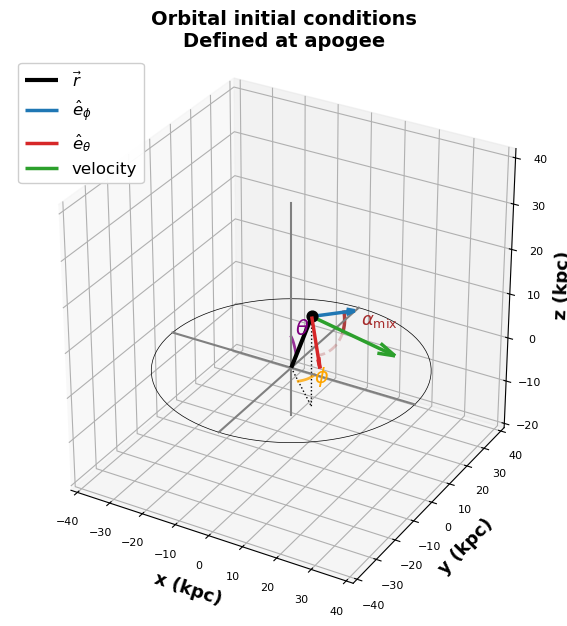

(<Figure size 620x620 with 1 Axes>,
 <Axes3D: title={'center': 'Orbital initial conditions\nDefined at apogee'}, xlabel='x (kpc)', ylabel='y (kpc)', zlabel='z (kpc)'>)

(<Figure size 620x620 with 1 Axes>,
 <Axes3D: title={'center': 'Orbital initial conditions\nDefined at apogee'}, xlabel='x (kpc)', ylabel='y (kpc)', zlabel='z (kpc)'>)

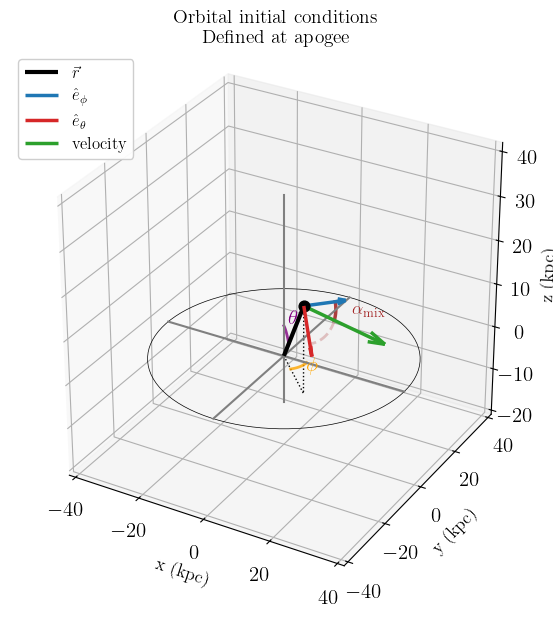

(<Figure size 620x620 with 1 Axes>,
 <Axes3D: title={'center': 'Orbital initial conditions\nDefined at apogee'}, xlabel='x (kpc)', ylabel='y (kpc)', zlabel='z (kpc)'>)

(<Figure size 620x620 with 1 Axes>,
 <Axes3D: title={'center': 'Orbital initial conditions\nDefined at apogee'}, xlabel='x (kpc)', ylabel='y (kpc)', zlabel='z (kpc)'>)

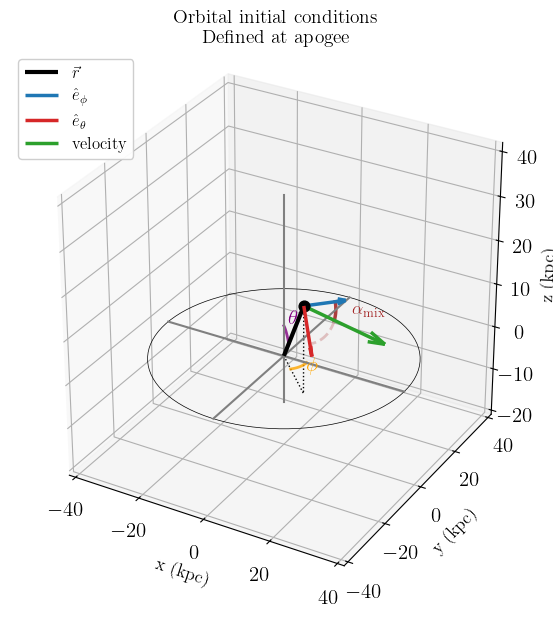

In [5]:
radius      = 2*s0
eccen       = 0.4
theta       = np.pi/4
phi         = -np.pi/4
polar_mix   = .5

potential   = tstrippy.potentials.exponential_oblate_halo
params      = [G,rho0,s0,q]
rvec,vvec,azimuth_hat,merdional_hat   = tstrippy.code.orbits.apoapsis_shot(potential=potential,params=params,radius=radius,eccen=eccen,theta=theta,phi=phi,polar_mix=polar_mix,getVecs=True)
initial_kinematics = [[rvec[0]],[rvec[1]],[rvec[2]],[vvec[0]],[vvec[1]],[vvec[2]]]
plot_initial_orbital_conditions_geometry(rvec,vvec,azimuth_hat,merdional_hat,theta,phi,polar_mix,figsize=(6.2,6.2))

## integration parameters 
 compute the timestep and dynamical time based on the properties of the system 

In [6]:
dt = Tchar/1e4
integration_time = 20*Tchar
NSTEPS = int(integration_time/dt)
integration_time = NSTEPS*dt
t_years=integration_time*(u.s * (u.kpc/u.km)).to(u.yr)
dt_years=dt*(u.s * (u.kpc/u.km)).to(u.yr)
print("{:25s}: {:.2e} years".format("total integration time", t_years))
print("{:25s}: {:.2e} years".format("integration time step", dt_years))
print("{:25s}: {:d} ".format("NSTEPS", NSTEPS))
integration_params = [0,dt,NSTEPS]

total integration time   : 1.01e+09 years
integration time step    : 5.05e+03 years
NSTEPS                   : 200000 


## Integrate 
Explore changing $\ell_{\rm{max}}$

In [7]:
lmaxes = np.arange(2,50,2)
rmin,rmax,nr = 1e-4, 1e3, int(1e2)
comptimes = np.zeros_like(lmaxes)
rgrid = np.logspace(np.log10(rmin),np.log10(rmax),nr)
results = np.zeros((lmaxes.shape[0],6,NSTEPS+1))

In [24]:
for i in range(lmaxes.shape[0]):
    starttime = datetime.datetime.now()
    tstrippy.integrator.deallocate()
    tstrippy.integrator.clearaxisymmetricbasisexpansion()
    tstrippy.integrator.initaxisymmetricbasisexpansion(G,lmaxes[i],rgrid)
    tstrippy.integrator.setinitialkinematics(*initial_kinematics)
    tstrippy.integrator.setintegrationparameters(*integration_params)
    tstrippy.integrator.setstaticgalaxy(*staticgalaxy)
    xt,yt,zt,vxt,vyt,vzt=tstrippy.integrator.leapfrogintime(NSTEPS,1)
    xt,yt,zt,vxt,vyt,vzt=xt[0],yt[0],zt[0],vxt[0],vyt[0],vzt[0]
    timestamps = tstrippy.integrator.timestamps.copy()
    endtime=datetime.datetime.now()
    comptime = endtime-starttime
    comptimes[i]=comptime.microseconds
    results[i][0]=xt
    results[i][1]=yt
    results[i][2]=zt
    results[i][3]=vxt
    results[i][4]=vyt
    results[i][5]=vzt
R = np.sqrt(np.sum(results[:,0:2,:]**2,axis=1))

# Convergence analysis 

Perform a convergence analysis. Compare all cases to the reference, which is $\ell_{\rm{max}}=50$


In [25]:
RMS = np.zeros((lmaxes.shape[0]-1,NSTEPS+1))
for i in range(lmaxes.shape[0]-1):
    diff = results[i] - results[-1]
    RMS[i] = np.sqrt(np.sum(np.abs(diff**2 / results[-1]),axis=0)) 

In [26]:
NPEAKS = 10
SIGNALINDEX = -1
peaks, properties = signal.find_peaks(RMS[SIGNALINDEX],distance=20)
# get the strongest 50
peaks=peaks[np.argsort(RMS[SIGNALINDEX][peaks])[::-1][:NPEAKS]]

In [27]:
# get the density map 
def density_oblate_halo(params,x,y,z):
    rho,s,q = params
    R = np.sqrt(x**2 + y**2)
    return rho * np.exp(-(1/s) * np.sqrt((R**2 + (z/q)**2)))

In [28]:
# get the density map 
npoints = 100
zmax = np.max(np.abs(results[-1][2][:]))
Rs = np.linspace(-R.max(),R.max(),npoints)
zs = np.linspace(-zmax,zmax,npoints)
RS,ZS = np.meshgrid(Rs,zs,indexing="xy")
RHO = np.zeros_like(RS)
for i in range(npoints):
    RHO[i] = density_oblate_halo([rho0,s0,q],RS[i],np.zeros_like(Rs), ZS[i])

Text(0.5, 1.0, '$\\rho(R,z)=\\rho_0\\exp\\!\\left[-\\frac{1}{s_0}\\sqrt{R^2+\\frac{z^2}{q^2}}\\right]$')

Text(0.5, 1.0, '$\\rho(R,z)=\\rho_0\\exp\\!\\left[-\\frac{1}{s_0}\\sqrt{R^2+\\frac{z^2}{q^2}}\\right]$')

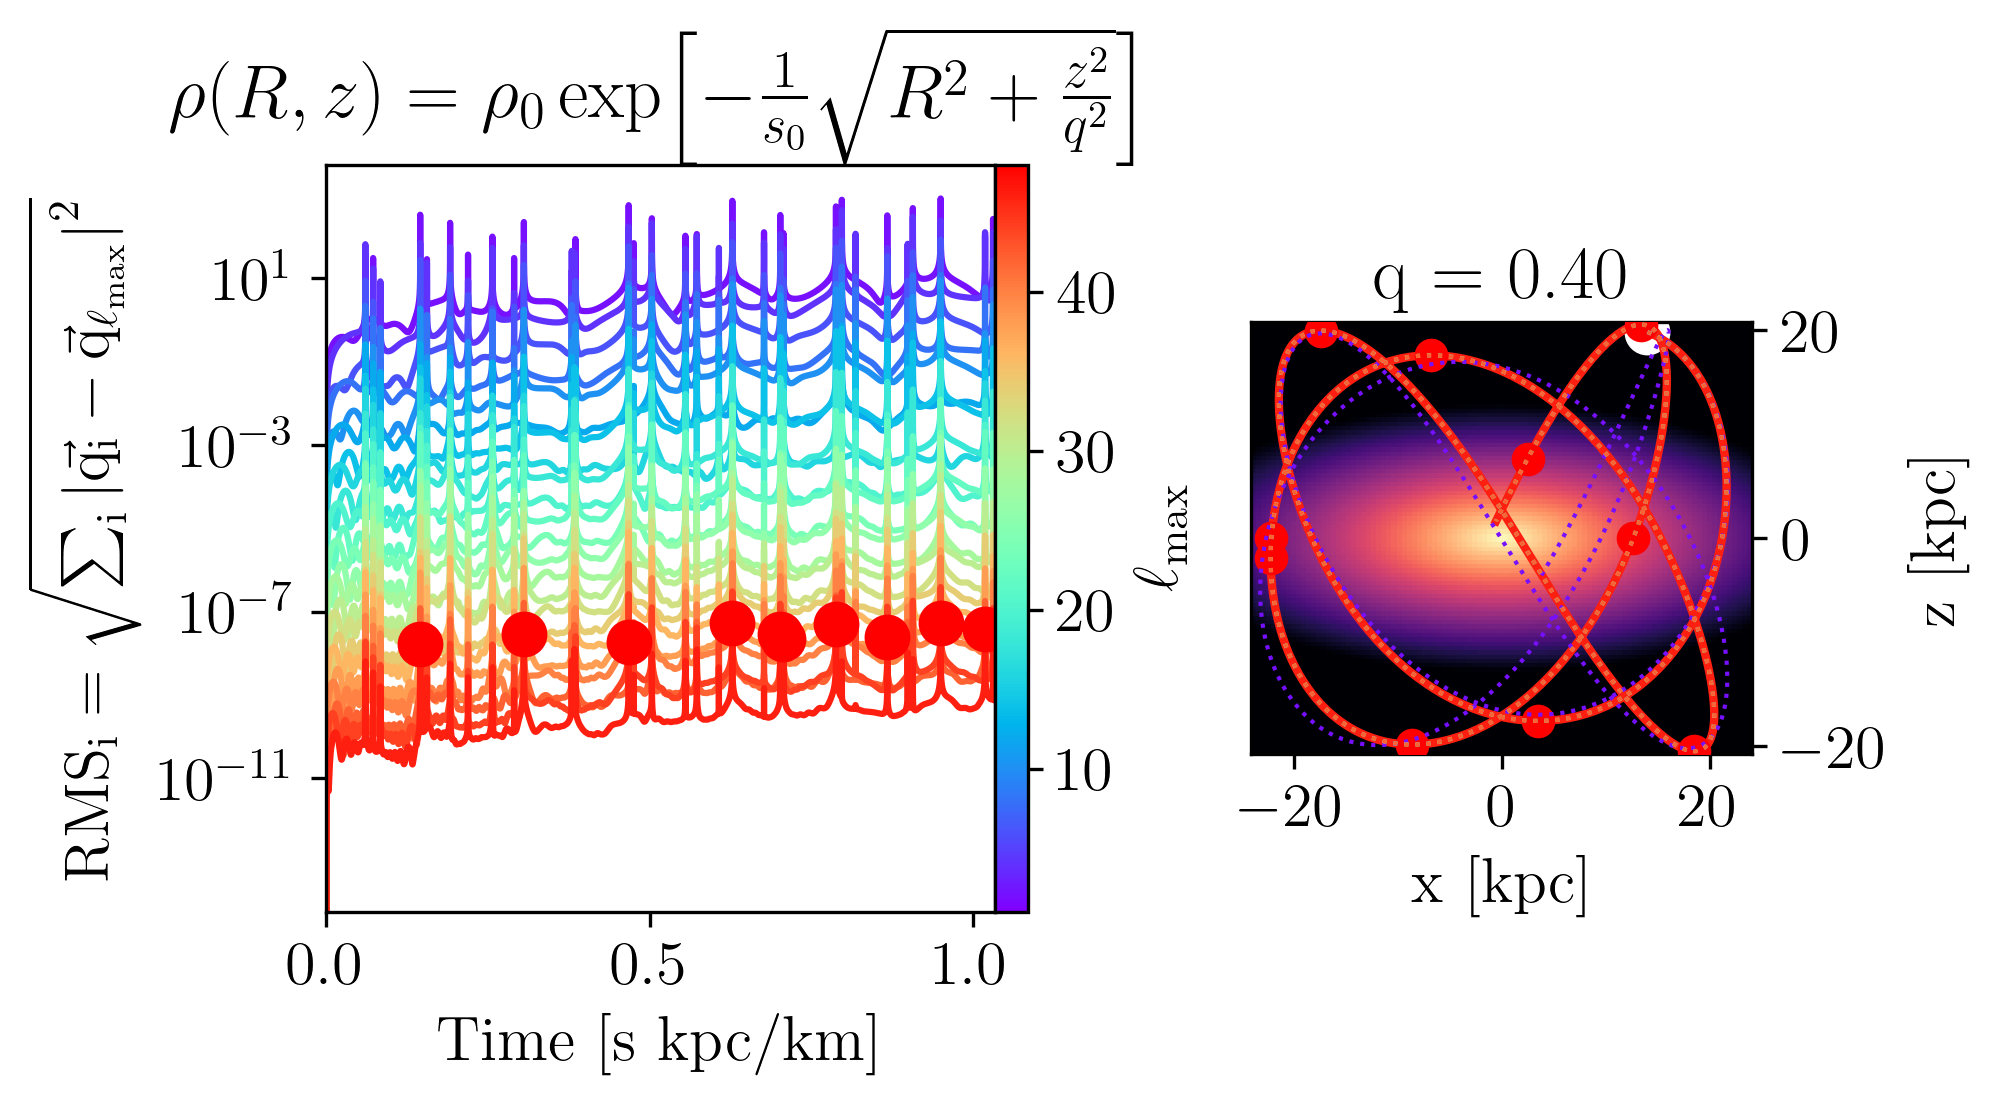

In [29]:
# colors for the l_max
cmap=plt.get_cmap("rainbow")
norm=plt.cm.colors.Normalize(vmin=1,vmax=lmaxes[-1])
colors = [cmap(norm(myl)) for myl in lmaxes ]

fig, ax_left, ax_cbar, ax_right = make_a4_three_panel_layout(width_ratios=(1, 1/20, 3/4),cbar_right_gap_ratio=1/3,fig_height_in=3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=ax_cbar)
cbar.set_label(r"$\ell_{\rm{max}}$")
for i in range(lmaxes.shape[0]-1):
    ax_left.plot(timestamps,RMS[i],color=colors[i])
ax_left.set_yscale("log")
ax_left.set_xlim(timestamps[0],timestamps[-1])
ax_left.set_ylabel(r"$\rm{{RMS}}_{{i}} = \sqrt{\sum_{i} \left| \vec{q_i} - \vec{q}_{\ell_{\rm{max}}} \right|^2}$")
# ax_left.set_ylabel(r"$\rm{RMS}_{i} = \sqrt{\sum_{i}\left|\vec{q_i} - \vec{q}_{\ell_{\rm{max}}}\right|^2$")

ax_right.set_aspect("equal")
ax_right.set_xlabel("x [kpc]")
ax_right.set_ylabel("z [kpc]")
cmapDensity = plt.get_cmap("magma")
logNorm = plt.cm.colors.LogNorm(1e-1*rho0,1e0*rho0)
ax_right.pcolormesh(RS, ZS, RHO, shading="auto", cmap=cmapDensity, norm=logNorm,)

# i=-1
ax_right.plot(results[i][0],results[i][2],color=colors[i],zorder=10+i,linewidth=2)
ax_right.scatter(results[-1][0][peaks],results[-1][2][peaks],color=colors[-1],s=50,zorder=100)
NSKIP = 10
for i in range(0,lmaxes.shape[0],NSKIP):
    ax_right.plot(results[i][0],results[i][2],color=colors[i],zorder=100+i, linestyle=":",linewidth=1)
ax_left.scatter(timestamps[peaks],RMS[SIGNALINDEX][peaks],s=100,color=colors[-1],zorder=100)
ax_right.scatter(results[0][0][0],results[0][2][0],color="w",s=100)
ax_left.set_xlabel(r"Time [s kpc/km]")
ax_right.set_title("q = {:.2f}".format(q))
ax_left.set_title(r"$\rho(R,z)=\rho_0\exp\!\left[-\frac{1}{s_0}\sqrt{R^2+\frac{z^2}{q^2}}\right]$")


## Compt time 

Investigate how the computation time scales with $\ell_{\rm{max}}$

(2.0, 48.0)

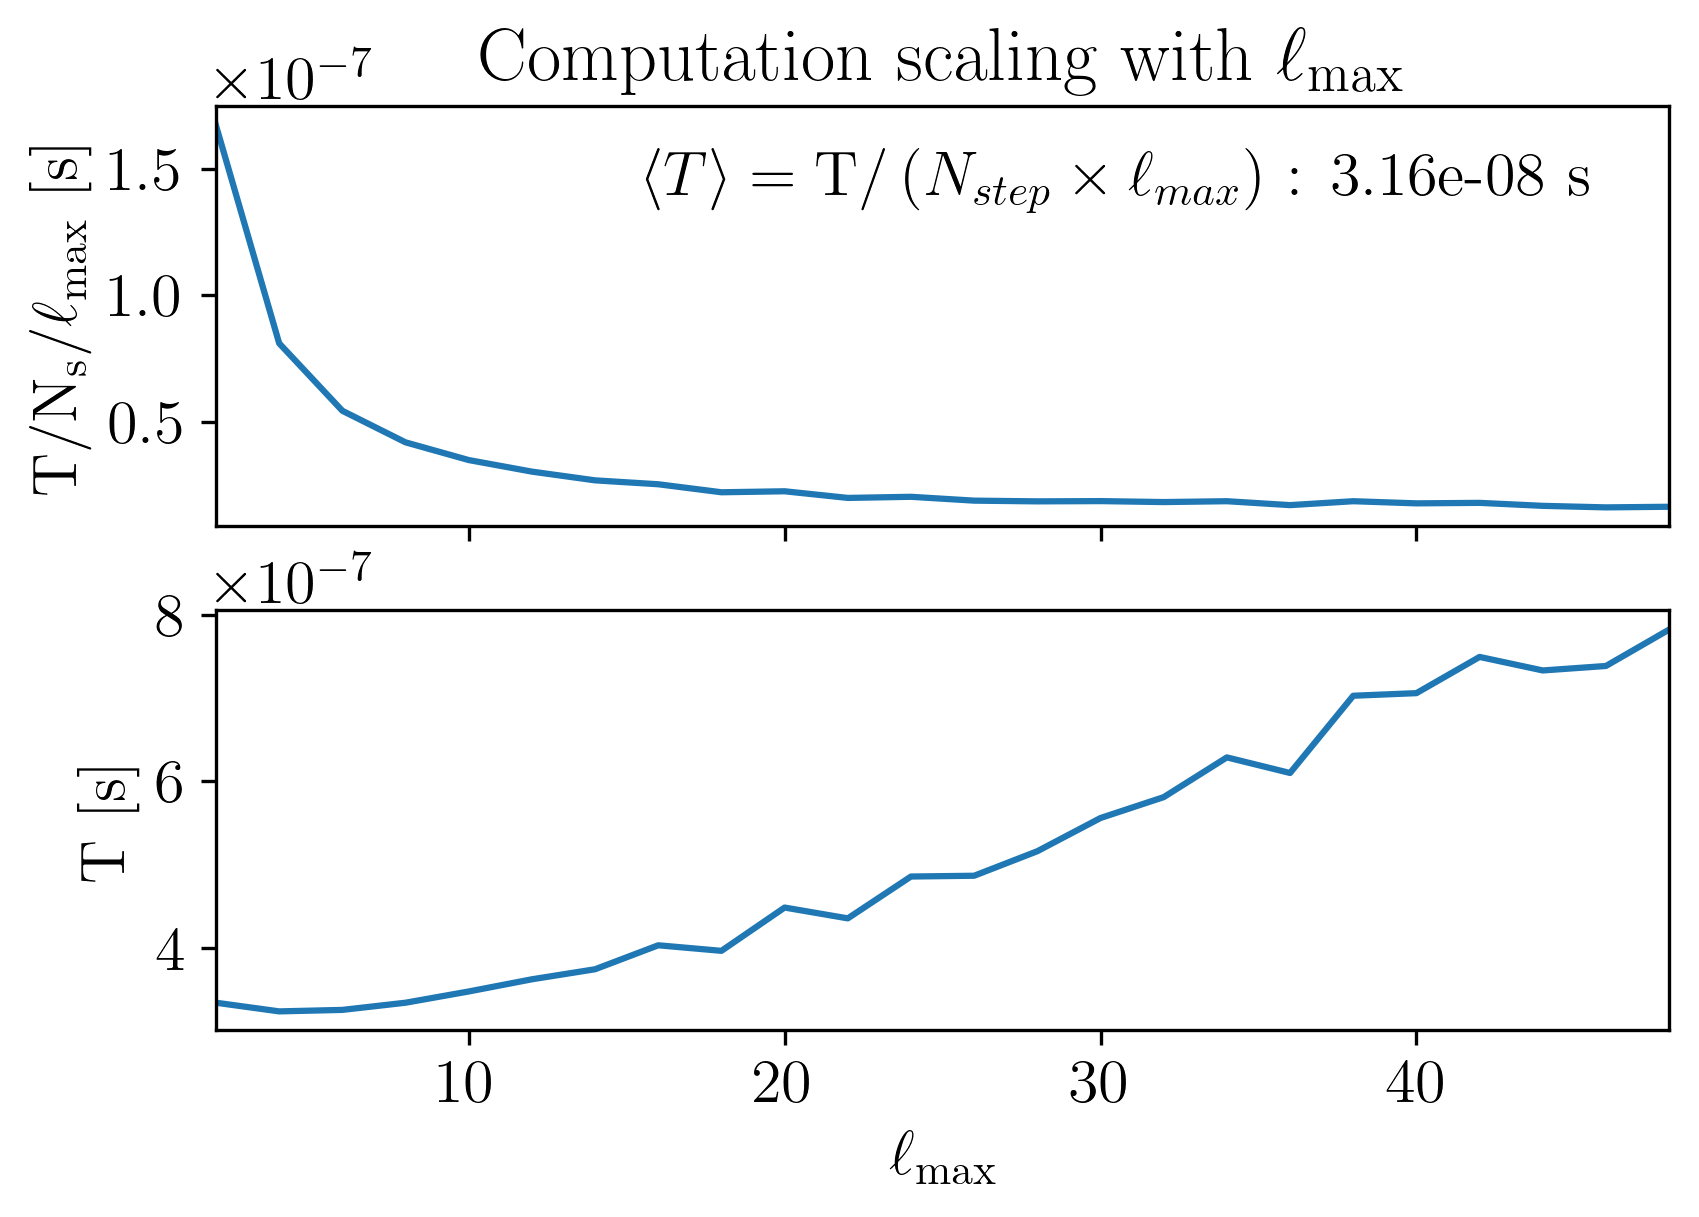

In [77]:
meancomptime = np.mean(comptimes/1e6/lmaxes/NSTEPS,)
fig,axis=plt.subplots(2,1,figsize=(8.25-2,4),sharex=True,dpi=300)
axis[0].plot(lmaxes,comptimes/1e6/lmaxes/NSTEPS)
axis[0].text(
    0.95, 0.9,
    r"$\left<T\right> = \mathrm{T} / \left( N_{step}\times \ell_{max}\right)$"+" : {:9.2e} s ".format(meancomptime),
    transform=axis[0].transAxes,
    ha="right",
    va="top",
)
axis[1].plot(lmaxes,comptimes/1e6/NSTEPS)

axis[0].set_ylabel(r"$\rm{T} /  N_{s} / \ell_{max}$ [s]")
axis[1].set_ylabel(r"T [s]")

axis[0].set_title(r"Computation scaling with $\ell_{\rm{max}}$")
axis[1].set_xlabel(r"$\ell_{\rm{max}}$")

axis[0].set_xlim(lmaxes.min(),lmaxes.max())

## Remark.

The computation time scales linearly per $\ell_{\rm{max}}$. Amazing! 